# Loan Approval Prediction System

## Goal
The goal of this project is to build a machine learning model that predicts whether a loan application should be approved or rejected based on applicant financial information.

Banks receive thousands of loan applications and evaluating them manually can be time-consuming. Using machine learning, we can automate this process and assist banks in making faster and more accurate decisions.

## Objectives

• Perform exploratory data analysis (EDA)  
• Clean and preprocess the dataset  
• Select important features  
• Train machine learning models  
• Evaluate model performance  
• Prepare the model for deployment

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Dataset Description

The dataset contains information about loan applicants including their income, credit score, loan amount, employment history, and other attributes.

### Features

• name – Applicant name  
• city – Applicant location  
• income – Applicant income  
• credit_score – Credit score of the applicant  
• loan_amount – Amount of loan requested  
• years_employed – Number of years employed  
• points – Additional evaluation points  
• loan_approved – Target variable (True / False)

In [2]:

url = "https://drive.google.com/uc?id=1amVm0YLJgiw9DlcQvhTILkuz-xFLU6Gb"

df = pd.read_csv(url)

df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50.0,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55.0,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45.0,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50.0,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25.0,False


In [3]:
# Dataset shape

df.shape

(2000, 8)

In [4]:
# Data types and missing values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            2000 non-null   object 
 1   city            2000 non-null   object 
 2   income          2000 non-null   int64  
 3   credit_score    2000 non-null   int64  
 4   loan_amount     2000 non-null   int64  
 5   years_employed  2000 non-null   int64  
 6   points          2000 non-null   float64
 7   loan_approved   2000 non-null   bool   
dtypes: bool(1), float64(1), int64(4), object(2)
memory usage: 111.5+ KB


In [5]:
# Statistical summary

df.describe()

,income,credit_score,loan_amount,years_employed,points
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,90585.977000,573.946000,25308.503000,20.441000,56.680000
std,34487.874907,160.564945,14207.320147,11.777813,18.638033
min,30053.000000,300.000000,1022.000000,0.000000,10.000000
25%,61296.250000,433.000000,12748.750000,10.000000,45.000000
50%,90387.500000,576.000000,25661.500000,21.000000,55.000000
75%,120099.750000,715.000000,37380.500000,31.000000,70.000000
max,149964.000000,850.000000,49999.000000,40.000000,100.000000


In [6]:
df.isnull().sum()

name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

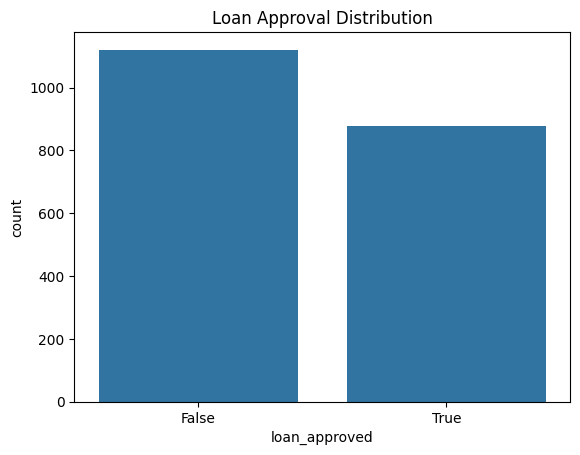

In [7]:
sns.countplot(x="loan_approved", data=df)
plt.title("Loan Approval Distribution")
plt.show()

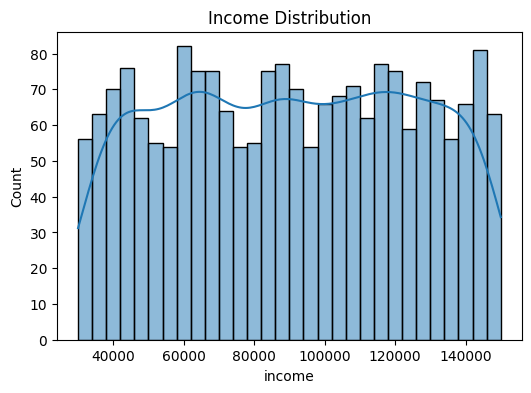

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(df["income"], bins=30, kde=True)
plt.title("Income Distribution")
plt.show()

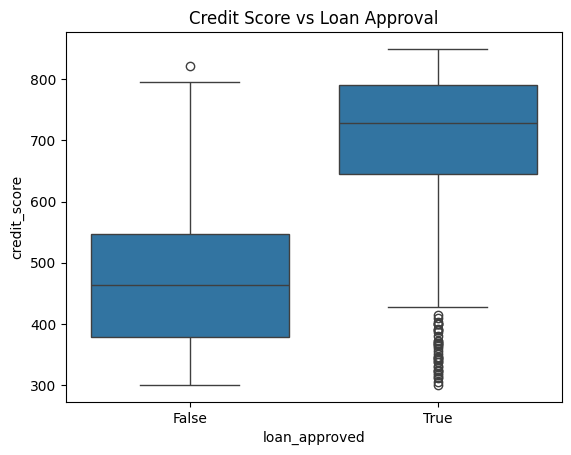

In [9]:
sns.boxplot(x="loan_approved", y="credit_score", data=df)
plt.title("Credit Score vs Loan Approval")
plt.show()

We remove unnecessary features like:

• name
• city

because they do not contribute to loan approval prediction.

In [10]:
df = df.drop(["name","city"], axis=1)

In [11]:
X = df.drop("loan_approved", axis=1)
y = df["loan_approved"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

In [14]:
rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [15]:
accuracy_score(y_test, dt_predictions)

1.0

In [16]:
accuracy_score(y_test, rf_predictions)

1.0

In [17]:
confusion_matrix(y_test, rf_predictions)

array([[217,   0],
       [  0, 183]])

In [18]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       217
        True       1.00      1.00      1.00       183

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



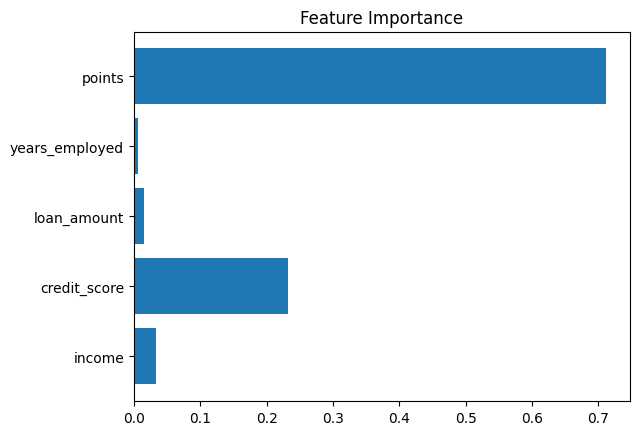

In [19]:
importance = rf_model.feature_importances_

features = X.columns

plt.barh(features, importance)

plt.title("Feature Importance")

plt.show()

In [20]:
import pickle

pickle.dump(rf_model, open("loan_model.pkl", "wb"))